## Problem Statement

You are a data scientist / AI engineer at an educational consulting firm. You have been provided with a dataset named **`student_scores.csv`**, which includes records of the number of hours students studied and the marks they obtained.

### Dataset Description

The dataset comprises the following columns:

| Column | Description |
|--------|-------------|
| `hours` | The number of hours a student studied |
| `scores` | The marks obtained by the student |

### Your Task

Your task is to use this dataset to build a **polynomial regression model** to predict the marks of students based on the number of hours they studied. You will need to:

1. Split the data into training and test sets
2. Train the model
3. Evaluate its performance using appropriate metrics

In [1]:
#Import all the necessary libraries 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
print(f"All necessary libraries imported")

All necessary libraries imported


In [2]:
#Load the data onto the dataframe
df = pd.read_csv('student_scores.csv')
print(df)

    hours  scores
0     4.4    20.0
1     9.6    90.0
2     7.6    58.0
3     6.4    31.0
4     2.4     5.0
..    ...     ...
95    5.4    26.0
96    5.7    32.0
97    4.8    25.0
98    1.2     3.0
99    2.0     8.0

[100 rows x 2 columns]


In [3]:
#Description and information about the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   hours   100 non-null    float64
 1   scores  100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


In [4]:
df.describe()

,hours,scores
count,100.000000,100.000000
mean,5.233000,34.510000
std,2.681438,29.167401
min,1.000000,0.000000
25%,2.775000,10.000000
50%,5.150000,25.000000
75%,7.600000,59.000000
max,9.900000,100.000000


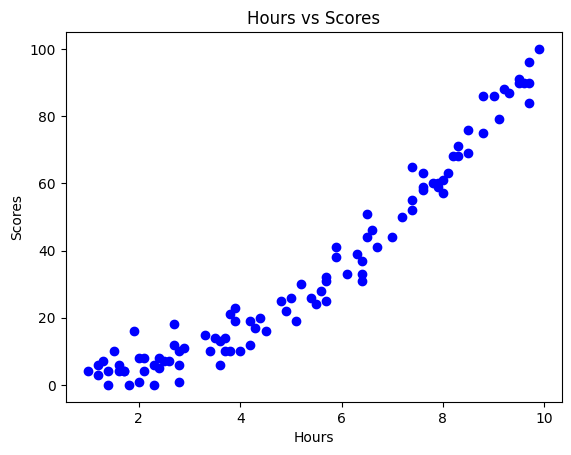

In [5]:
#Scatter plot to check the nature of the data
X = df[['hours']]
y = df['scores']
plt.scatter(X,y,color='blue')
plt.xlabel('Hours')
plt.ylabel('Scores')
plt.title("Hours vs Scores")
plt.show()

In [7]:
#Split the data using train_test_split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state =42)

In [16]:
#Load the polynomial model processor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
degree = 2
model = make_pipeline(
    PolynomialFeatures(degree),
    LinearRegression()
)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [17]:
#Evaluate the model metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
y_pred = model.predict(X_test)
#Calculate metrics
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print(f"Mean absolute error: {mae:.2f}")
print(f"Mean squared error: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")

Mean absolute error: 2.69
Mean squared error: 12.99
R2 Score: 0.99
